<a href="https://colab.research.google.com/github/euleralencar/projeto_ciencia_dados_ibmec/blob/main/02_1_numerical_pipeline_introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primeiro modelo com o scikit-learn

Neste notebook, apresentamos como construir modelos preditivos em conjuntos de
dados tabulares, usando apenas variáveis numéricas.

Em particular, destacamos:

* a API do scikit-learn: `.fit(X, y)`/`.predict(X)`/`.score(X, y)`;
* como avaliar o desempenho de generalização de um modelo com uma divisão
  treino-teste.

Aqui, API significa "Application Programming Interface" (Interface de
Programação de Aplicações) e se refere a um conjunto de convenções para
construir softwares consistentes. Note que você pode visitar o Glossário para
mais informações sobre jargão técnico.

## Carregando o conjunto de dados com o Pandas

Usamos o conjunto de dados "adult_census", descrito no notebook anterior. Para
mais detalhes sobre o conjunto de dados, veja <http://www.openml.org/d/1590>.

Dados numéricos são o tipo de dado mais natural usado em aprendizado de máquina
e podem (quase) ser diretamente inseridos em modelos preditivos. Aqui,
carregamos um subconjunto dos dados originais contendo apenas as colunas
numéricas.

In [2]:
import pandas as pd

adult_census = pd.read_csv(
    "https://raw.githubusercontent.com/INRIA/scikit-learn-mooc/main/datasets/adult-census-numeric.csv"
)

In [3]:
#test_target_name = "class"
#target_test = adult_census_test[test_target_name]
#data_test = adult_census_test.drop(columns=[test_target_name])

Vamos dar uma olhada nos primeiros registros deste dataframe:

In [4]:
adult_census

,age,capital-gain,capital-loss,hours-per-week,class
0,41,0,0,92,<=50K
1,48,0,0,40,<=50K
2,60,0,0,25,<=50K
3,37,0,0,45,<=50K
4,73,3273,0,40,<=50K
...,...,...,...,...,...
39068,45,0,0,40,<=50K
39069,47,0,0,60,<=50K
39070,29,0,1485,60,>50K
39071,29,0,0,40,<=50K


Vemos que este arquivo CSV contém todas as informações: o alvo que gostaríamos
de prever (ou seja, `"class"`) e os dados que queremos usar para treinar nosso
modelo preditivo (ou seja, as colunas restantes). O primeiro passo é separar as
colunas para obter, de um lado, o alvo e, de outro, os dados.

## Separar os dados e o alvo

In [5]:
target_name = "class"
target = adult_census[target_name]
target

,class
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
39068,<=50K
39069,<=50K
39070,>50K
39071,<=50K


In [6]:
data = adult_census.drop(columns=[target_name])
data

,age,capital-gain,capital-loss,hours-per-week
0,41,0,0,92
1,48,0,0,40
2,60,0,0,25
3,37,0,0,45
4,73,3273,0,40
...,...,...,...,...
39068,45,0,0,40
39069,47,0,0,60
39070,29,0,1485,60
39071,29,0,0,40


Agora podemos focar nas variáveis, também chamadas de features, que usaremos
mais adiante para construir nosso modelo preditivo. Além disso, também podemos
verificar quantas amostras estão disponíveis em nosso conjunto de dados.

In [7]:
data.columns

Index(['age', 'capital-gain', 'capital-loss', 'hours-per-week'], dtype='object')

In [8]:
print(
    f"O conjunto de dados contém {data.shape[0]} amostras e "
    f"{data.shape[1]} features"
)

O conjunto de dados contém 39073 amostras e 4 features


## Ajustar um modelo e fazer previsões

Agora construímos um modelo de classificação usando a estratégia "K-nearest
neighbors". Para prever o alvo de uma nova amostra, o k-nearest neighbors leva
em conta suas `k` amostras mais próximas no conjunto de treino e prevê o alvo
majoritário dessas amostras.

<div class="admonition caution alert alert-warning">
<p class="first admonition-title" style="font-weight: bold;">Cuidado!</p>
<p class="last">Usamos aqui o K-nearest neighbors. No entanto, saiba que ele
raramente é útil na prática. Nós o usamos porque é um algoritmo intuitivo. No
próximo notebook, apresentaremos modelos melhores.</p>
</div>

O método `fit` é chamado para treinar o modelo a partir dos dados de entrada
(features) e do alvo.

In [10]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
_ = model.fit(data, target)

O aprendizado pode ser representado da seguinte forma:

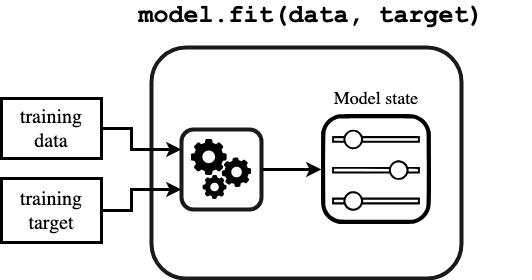

No scikit-learn, um objeto que possui um método `fit` é chamado de
**estimador**. Se o estimador também tiver :
- um método `predict`, ele é chamado de **preditor**. Exemplos de preditores
  são classificadores ou regressores.
- um método `transform`, ele é chamado de **transformador**. Exemplos de
  transformadores são escalonadores ou codificadores. Veremos mais sobre
  transformadores no próximo notebook.

O método `fit` é composto por dois elementos: (i) um **algoritmo de
aprendizado** e (ii) alguns **estados do modelo**. O algoritmo de aprendizado
recebe os dados de treino e o alvo de treino como entrada e define os estados
do modelo. Esses estados do modelo são usados posteriormente para prever ou
transformar dados, como explicado acima. Veja o glossário para definições mais
detalhadas.

Tanto o algoritmo de aprendizado quanto o tipo de estados do modelo são
específicos para cada tipo de modelo.

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p class="last">Aqui e mais adiante, usamos os nomes <tt class="docutils
literal">data</tt> e <tt class="docutils literal">target</tt> para sermos
explícitos. Na documentação do scikit-learn, <tt class="docutils
literal">data</tt> é comumente chamado de <tt class="docutils literal">X</tt> e
<tt class="docutils literal">target</tt> é comumente chamado de <tt
class="docutils literal">y</tt>.</p>
</div>

Vamos usar nosso modelo para fazer algumas previsões usando o mesmo conjunto de
dados.

In [11]:
target_predicted = model.predict(data)

Podemos ilustrar o mecanismo de previsão  da seguinte forma:

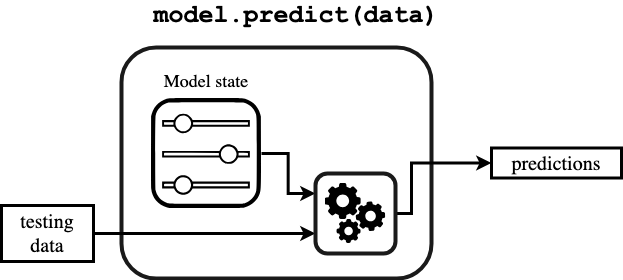

Para prever, um modelo usa uma **função de previsão** que utiliza os dados de
entrada em conjunto com os estados do modelo. Assim como o algoritmo de
aprendizado e os estados do modelo, a função de previsão é específica para cada
tipo de modelo.

Agora vamos dar uma olhada nas previsões calculadas. Para simplificar,
observamos os cinco primeiros alvos previstos.

In [12]:
target_predicted[:5]

array([' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K'], dtype=object)

De fato, podemos comparar essas previsões com os dados reais...

In [13]:
target[:5]

,class
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


...e poderíamos até verificar se as previsões concordam com os alvos reais:

In [14]:
target[:5] == target_predicted[:5]

,class
0,False
1,True
2,True
3,True
4,True


In [15]:
print(
    "Número de previsões corretas: "
    f"{(target[:5] == target_predicted[:5]).sum()} / 5"
)

Número de previsões corretas: 4 / 5


Aqui, vemos que nosso modelo comete um erro ao prever a primeira amostra.

Para obter uma avaliação melhor, podemos calcular a taxa média de acerto.

In [16]:
(target == target_predicted).mean()

np.float64(0.8242776341719346)

Esse resultado significa que o modelo faz uma previsão correta para
aproximadamente 82 amostras em cada 100. Note que usamos os mesmos dados para
treinar e avaliar nosso modelo. Essa avaliação pode ser confiável ou é boa
demais para ser verdade?

## Divisão treino-teste dos dados

Ao construir um modelo de aprendizado de máquina, é importante avaliar o modelo
treinado em dados que não foram usados para ajustá-lo, já que **generalização**
é mais do que memorização (ou seja, queremos uma regra que generalize para
novos dados, sem comparar com dados que memorizamos). É mais difícil concluir
algo sobre instâncias nunca vistas do que sobre instâncias já vistas.

Uma avaliação correta é facilmente feita deixando de fora um subconjunto dos
dados durante o treinamento do modelo e usando-o depois para avaliar o modelo.
Os dados usados para ajustar um modelo são chamados de dados de treino,
enquanto os dados usados para avaliar um modelo são chamados de dados de teste.

Podemos carregar mais dados, que na verdade foram deixados de fora do conjunto
de dados original.

In [17]:
adult_census_test = pd.read_csv(
    "https://raw.githubusercontent.com/INRIA/scikit-learn-mooc/main/datasets/adult-census-numeric-test.csv"
)

A partir desses novos dados, separamos nossas features de entrada e o alvo a
ser previsto, como no início deste notebook.

In [18]:
test_target_name = "class"
target_test = adult_census_test[test_target_name]
data_test = adult_census_test.drop(columns=[test_target_name])

Podemos verificar o número de features e amostras disponíveis neste novo
conjunto.

In [19]:
print(
    f"O conjunto de dados de teste contém {data_test.shape[0]} amostras e "
    f"{data_test.shape[1]} features"
)

O conjunto de dados de teste contém 9769 amostras e 4 features


Em vez de calcular a previsão e depois calcular manualmente a taxa média de
acerto, podemos usar o método `score`. Ao lidar com classificadores, esse
método retorna sua métrica de desempenho.

In [20]:
accuracy = model.score(data_test, target_test)
model_name = model.__class__.__name__

print(f"A acurácia no teste usando um {model_name} é {accuracy:.3f}")

A acurácia no teste usando um KNeighborsClassifier é 0.804


Usamos o termo genérico **modelo** para objetos cuja qualidade de ajuste pode ser medida usando o método `score`. Vamos ver o mecanismo por trás da chamada de `score`:

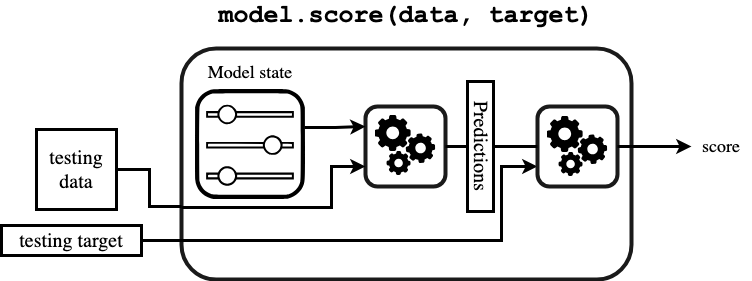

Para calcular o score, o preditor primeiro calcula as previsões (usando o método `predict`) e depois usa uma função de pontuação para comparar o alvo verdadeiro `y` com as previsões. Por fim, o score é retornado.

Se compararmos com a acurácia obtida ao avaliar incorretamente o modelo no
conjunto de treino, vemos que essa avaliação foi de fato otimista em comparação
com o score obtido em um conjunto de teste separado.

Isso mostra a importância de sempre testar o desempenho de generalização de
modelos preditivos em um conjunto diferente daquele usado para treiná-los.
Discutiremos mais adiante, em mais detalhes, como os modelos preditivos devem
ser avaliados.

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p class="last">Neste MOOC, nos referimos ao <strong>desempenho de
generalização</strong> de um modelo quando falamos do score de teste ou do erro
de teste obtido ao comparar a previsão de um modelo com os alvos verdadeiros.
Termos equivalentes para <strong>desempenho de generalização</strong> são
desempenho preditivo e desempenho estatístico. Nos referimos ao
<strong>desempenho computacional</strong> de um modelo preditivo ao avaliar os
custos computacionais de treinar um modelo preditivo ou usá-lo para fazer
previsões.</p>
</div>

## Recapitulando o notebook

Neste notebook, nós:

* ajustamos um modelo de **k-nearest neighbors** em um conjunto de dados de
  treino;
* avaliamos seu desempenho de generalização nos dados de teste;
* apresentamos a API do scikit-learn `.fit(X, y)` (para treinar um modelo),
  `.predict(X)` (para fazer previsões) e `.score(X, y)` (para avaliar um
  modelo);
* apresentamos o jargão de estimador, preditor e modelo.